# Data Visualization Ethics Challenge

In this activity, you’ll work with a simple dataset and examine two deliberately bad charts.  
Each one ignores multiple best practices for ethical and effective visualization.

Your job is to:

1. Review each chart and note at least three issues you see.  
2. Create a new chart (or charts) that present the data clearly, accurately, and honestly.  
3. Include clear labels, a cited data source, and a descriptive but neutral title.

**Remember:** Strong visualizations tell the truth, provide context, and avoid design choices that distort or mislead.


## Step 1: Load the dataset

We’re using a provided CSV file with fictional sales data for a coffee chain.  
No need to modify anything in this cell — just run it so the dataset loads into your notebook.  
Once loaded, take a quick look at the first few rows to get familiar with the columns and values.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

coffee_df = pd.read_csv("fake_coffee_chain_sales.csv")
coffee_df.head()

,Year,Month,Region,Category,Sales,Profit
0,2020,January,East,Espresso,14724,5290.46
1,2020,January,East,Lattes,11948,4138.77
2,2020,January,East,Tea,18660,5959.44
3,2020,January,East,Pastries,11265,2604.46
4,2020,January,East,Beans,8954,2613.22


In [2]:
coffee_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      1200 non-null   int64  
 1   Month     1200 non-null   str    
 2   Region    1200 non-null   str    
 3   Category  1200 non-null   str    
 4   Sales     1200 non-null   int64  
 5   Profit    1200 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 56.4 KB


## Step 2: Review the BAD Charts

Below are two deliberately poor visualizations.  
Your task: Carefully review each and take notes on what you think is wrong, misleading, or just poorly designed.  
Think about chart type, colors, scales, labeling, and whether the chart tells the truth.  


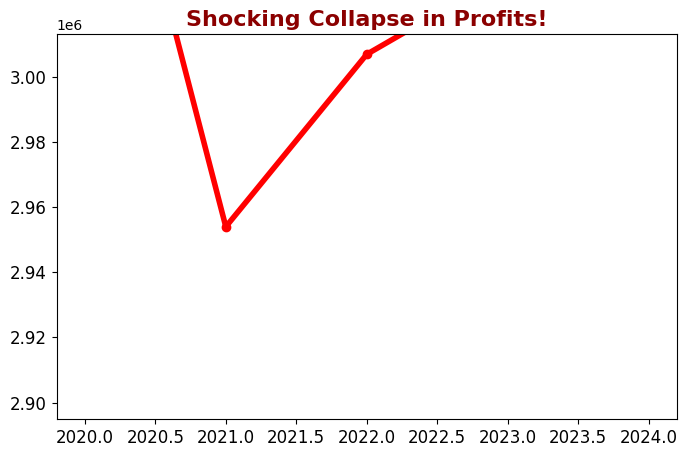

In [3]:
plt.figure(figsize=(8,5))
subset = coffee_df.groupby("Year")["Sales"].sum().reset_index()

# Wrong variable for title, truncated y-axis, misleading color & framing
plt.plot(subset["Year"], subset["Sales"], color="red", linewidth=4, marker="o")
plt.ylim(subset["Sales"].min() * 0.98, subset["Sales"].min() * 1.02)  # extreme truncation
plt.title("Shocking Collapse in Profits!", fontsize=16, fontweight="bold", color="darkred")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


### Write your notes about bad chart #1 here:
(double click to open this markdown cell and type into it)

1. X and Y axes are not labeled 
2. X axis - Years in Decimal values
3. Truncating the Y axis value - exaggerates the result
4. Misleading Title
5. Title could have been Total Sales per Year or Annual Sales
6. Misleading colors

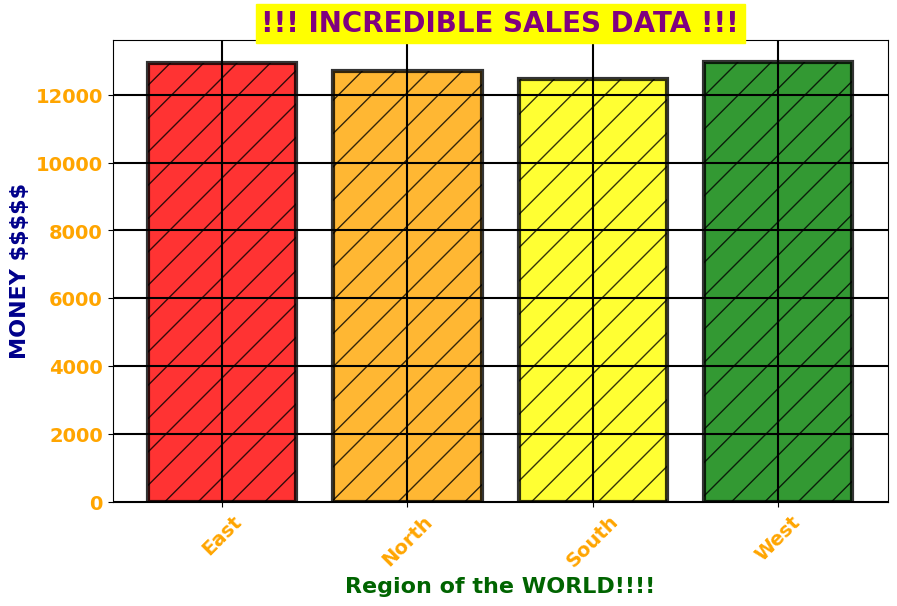

In [4]:
plt.figure(figsize=(10,6))
avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index()

colors = ["red","orange","yellow","green","blue","purple"]

plt.bar(avg_sales["Region"], avg_sales["Sales"], 
        color=colors, edgecolor="black", linewidth=3, hatch="/", alpha=0.8)
plt.title("!!! INCREDIBLE SALES DATA !!!", fontsize=20, fontweight="bold", color="purple", backgroundcolor="yellow")
plt.grid(True, which='both', color='black', linestyle='-', linewidth=1.5)
plt.xlabel("Region of the WORLD!!!!", fontsize=16, fontweight="bold", color="darkgreen")
plt.ylabel("MONEY $$$$$", fontsize=16, fontweight="bold", color="darkblue")
plt.xticks(rotation=45, fontsize=14, fontweight="bold", color="orange")
plt.yticks(fontsize=14, fontweight="bold", color="orange")
plt.show()


### Write your notes about bad chart #2 here:
(double click to open this markdown cell and type into it)

1. Exaggerated title, xlabel and ylabel
2. Strong colors for the bars
3. Too many distractions with lines (Chartjunk)


## Step 3: Your Turn – Make It Right

Now it’s your turn to fix things.  

- Start by thinking about a question you want to answer with this dataset.  
- Choose a visualization type that matches your question and the data structure.  
- Apply the best practices from our lessons: clear labeling, appropriate scale, purposeful color, simplicity, and accessibility.  
- Be honest - don’t manipulate the chart to make a point that the data doesn’t support.  

When you’re done, add your chart(s) below. You may create more than one if it helps tell the story better.  


In [5]:
# Your GOOD visualization(s) here

# What is the Total Sales Per Year?

subset = coffee_df.groupby("Year")["Sales"].sum().reset_index()
print(subset)

   Year    Sales
0  2020  3120583
1  2021  2953939
2  2022  3006869
3  2023  3031845
4  2024  3200372


### Visualization for Total Sales Per Year or Annual Sales

***Title: Total Sales Per Year***                 

***X-Axis labeled as Years and Y-Axis labeled as Sales***

Below visualization shows Total Sales from 2020 through 2024. In 2020, Sales was just over 3.1 Million, followed by a big drop to 2.95 Million in 2021. Sales has been on a steady growth trajectory since 2022, reaching over 3.2 Million in 2024. 

Note: the y-axis starts at 3.0 rather than 0 to better highlight the trend, as a zero-based axis would compress the variation and diminish the growth pattern.


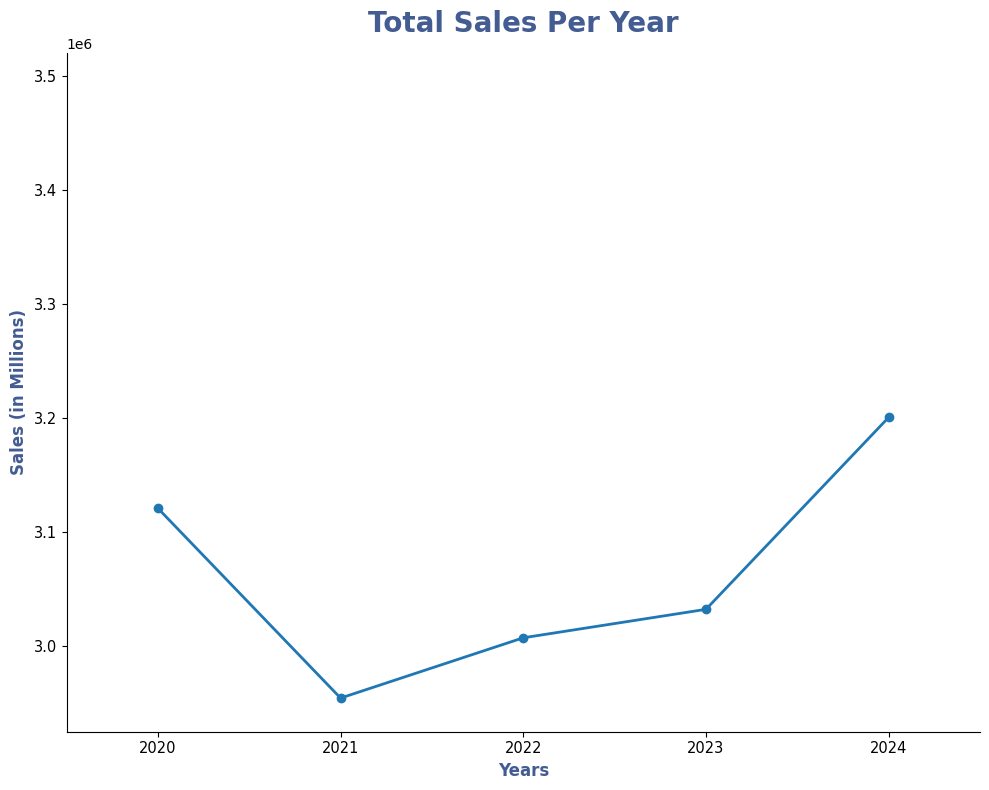

In [6]:
# Visualization - Total Sales Per Year or Annual Sales

plt.figure(figsize=(10,8))
plt.plot(subset["Year"], subset["Sales"], linewidth=2, marker="o")

plt.ylim(subset['Sales'].min()*.99, subset['Sales'].max()*1.1)
plt.xlim(subset["Year"].min()-0.5, subset['Year'].max()+0.5)

plt.title("Total Sales Per Year", fontsize=20, fontweight="bold", color ="#435c91ff", pad =15)
plt.xlabel("Years", fontsize = 12, fontweight ='bold', color ="#435c91ff")
plt.ylabel("Sales (in Millions)", fontsize = 12, fontweight ='bold',color ="#435c91ff")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(subset["Year"].unique(), fontsize=10.5)
plt.yticks(fontsize=10.5)

plt.tight_layout()
plt.show()

In [7]:
# To find the Average Sales Per Region

avg_sales = coffee_df.groupby("Region")["Sales"].mean().round(2).reset_index()
avg_sales = avg_sales.sort_values("Sales", ascending=False)
print(avg_sales)

  Region     Sales
3   West  12977.22
0   East  12923.38
1  North  12692.99
2  South  12451.78


### Visualization for Average Sales Per Region

***Title: Average Sales Per Region***

***X-Axis labeled - Regions and Y-Axis labeled - Average Sales***

The visualization below represents Average Sales across four Regions. The West region leads with the highest average sales of 12,977, followed closely by East (12,923) and North (12,692). The South region has the lowest average at 12,451. Overall, the difference between the highest and lowest region is only $525, suggesting sales performance is fairly consistent across regions with no single region significantly outperforming the others.



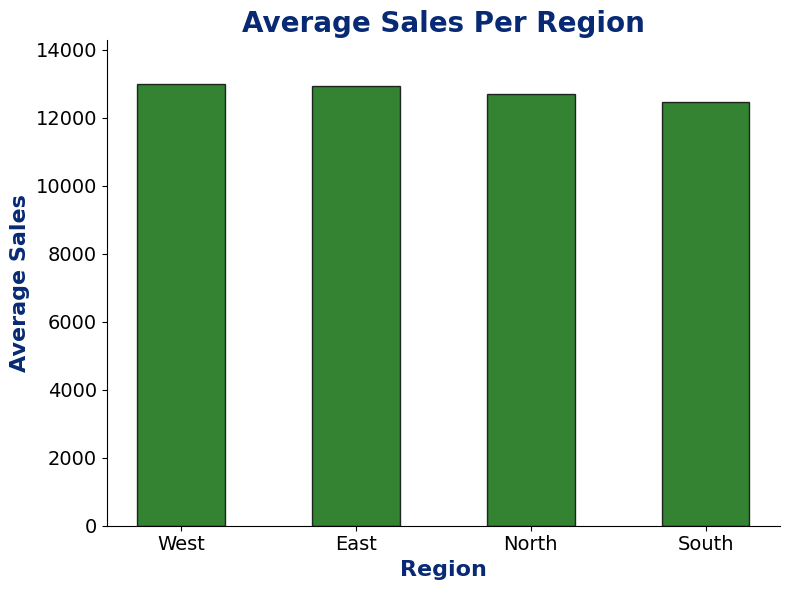

In [8]:
# Visualization for Average Sales Per Region

plt.figure(figsize=(8,6))
                    
plt.bar(avg_sales["Region"], avg_sales["Sales"], 
        color="darkgreen", edgecolor="black", width=0.5, alpha = 0.8)
plt.title("Average Sales Per Region", fontsize=20, fontweight="bold", color="#082a74ff")

plt.xlabel("Region", fontsize=16, fontweight="bold", color="#082a74ff")
plt.ylabel("Average Sales", fontsize=16, fontweight="bold", color="#082a74ff")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.ylim(0, avg_sales["Sales"].max() * 1.1)


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# To find Average profit by category for each year

Profit= coffee_df.groupby(["Category","Year"])["Profit"].mean().round(2).reset_index()

Profit = Profit.sort_values("Year")

print(Profit)


    Category  Year   Profit
0      Beans  2020  3951.79
5   Espresso  2020  3865.49
15  Pastries  2020  3992.76
10    Lattes  2020  3900.50
20       Tea  2020  3619.69
6   Espresso  2021  3997.25
1      Beans  2021  3634.13
11    Lattes  2021  3668.00
16  Pastries  2021  3363.74
21       Tea  2021  3844.66
2      Beans  2022  4018.27
22       Tea  2022  3630.52
17  Pastries  2022  3496.74
12    Lattes  2022  3786.85
7   Espresso  2022  3874.82
13    Lattes  2023  3947.51
3      Beans  2023  3831.72
18  Pastries  2023  4084.50
23       Tea  2023  3507.65
8   Espresso  2023  3749.72
14    Lattes  2024  4168.44
9   Espresso  2024  3810.85
4      Beans  2024  4268.42
19  Pastries  2024  3923.82
24       Tea  2024  3868.04


### Visualize the Average Profit by Category for each year

***Title : Average Profit Per Category***

***X-Axis - Year and Y-Axis - Average Profit***

The visualization below represents Average Profit by Category from 2020 to 2024, with each category listed in the legend. In 2020, Pastries led with the highest profit, while all categories performed fairly consistently. In 2021, Espresso and Tea held strong, but Beans, Lattes, and Pastries saw a relative dip in profit. By 2022, Beans recovered to post the highest profit, with most categories trending upward. In 2023, Pastries reclaimed the top spot, with most categories maintaining higher profits 
compared to 2022, except Tea which declined. In 2024, Beans achieved the highest profit, with Lattes and Tea also showing consistent growth.

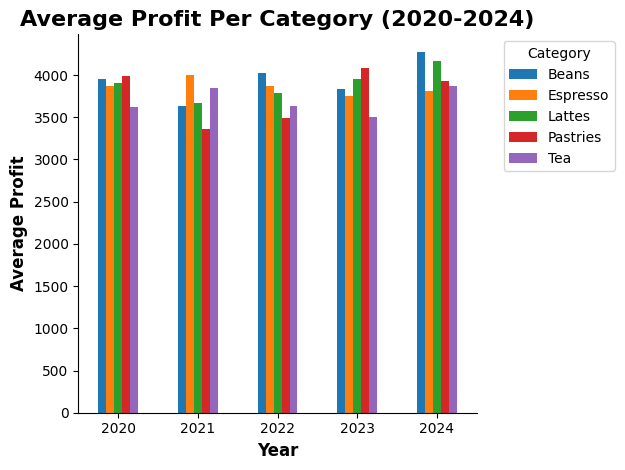

In [19]:
# Visualization to show Average Profit by Category

plt.Figure(figsize=(12,8))

grouped_result = Profit.pivot(index="Year", columns="Category", values="Profit")

grouped_result.plot(kind="bar", stacked=False)

plt.title("Average Profit Per Category (2020-2024)", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12, fontweight="bold")
plt.ylabel("Average Profit", fontsize=12, fontweight="bold")
plt.xticks( rotation = 0)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()